# **Detección de fraude - Ambos modelos (Arból de Decisión y Random Forest)**

### 1. Importación del Dataset "creditcard" para Detección de Fraude

Para este ejercicio, trabajaremos con el dataset "creditcard" usado para la detección de fraude, donde la clase de fraude (`1`) es minoritaria. Esto nos permitirá trabajar con un problema típico de desbalance de clases.

In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

# --- Instrucciones: Cargando el dataset 'creditcard' desde OpenML ---
# Este es un dataset público y conocido para detección de fraude.
# La primera vez que se ejecuta, puede tardar un poco en descargarse.
try:
    # ID 1597 corresponde al dataset 'creditcard' en OpenML
    df_fraude = fetch_openml(name='creditcard', version=1, as_frame=True, return_X_y=False).frame
    print("Dataset 'creditcard' cargado exitosamente desde OpenML.")
except Exception as e:
    print(f"Error al cargar el dataset desde OpenML: {e}")
    df_fraude = pd.DataFrame() # Crear DataFrame vacío en caso de error

# Mostrar las primeras 5 filas del dataset
if not df_fraude.empty:
    print("Primeras 5 filas del dataset de fraude:")
    display(df_fraude.head())

    # Mostrar información general del dataset
    print("\nInformación general del dataset:")
    df_fraude.info()

    # Contar la distribución de las clases (la columna objetivo se llama 'Class' en este dataset)
    if 'Class' in df_fraude.columns:
        print("\nDistribución de la variable objetivo 'Class':")
        display(df_fraude['Class'].value_counts(normalize=True).mul(100).astype(str) + '%')
    else:
        print("Advertencia: No se encontró la columna 'Class' en el dataset. Asegúrate de que el nombre de la columna objetivo sea correcto.")

Dataset 'creditcard' cargado exitosamente desde OpenML.
Primeras 5 filas del dataset de fraude:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   V1      284807 non-null  float64 
 1   V2      284807 non-null  float64 
 2   V3      284807 non-null  float64 
 3   V4      284807 non-null  float64 
 4   V5      284807 non-null  float64 
 5   V6      284807 non-null  float64 
 6   V7      284807 non-null  float64 
 7   V8      284807 non-null  float64 
 8   V9      284807 non-null  float64 
 9   V10     284807 non-null  float64 
 10  V11     284807 non-null  float64 
 11  V12     284807 non-null  float64 
 12  V13     284807 non-null  float64 
 13  V14     284807 non-null  float64 
 14  V15     284807 non-null  float64 
 15  V16     284807 non-null  float64 
 16  V17     284807 non-null  float64 
 17  V18     284807 non-null  float64 
 18  V19     284807 non-null  float64 
 19  V20     284807 non-null  float6

,proportion
Class,
0,99.82725143693798%
1,0.1727485630620034%


### 2. Preprocesamiento de Datos

En este paso, prepararemos el dataset para el entrenamiento de los modelos. Esto incluye: escalado de características para normalizar los rangos de valores, y la división del dataset en conjuntos de entrenamiento y prueba. No necesitamos manejar valores nulos ya que el dataset sintético no los tiene.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definir las características (X) y la variable objetivo (y)
# Asumimos que la columna objetivo se llama 'Class' en el dataset de creditcard.csv
if 'Class' in df_fraude.columns:
    X = df_fraude.drop('Class', axis=1)
    y = df_fraude['Class']
else:
    print("Error: La columna 'Class' no se encontró en el DataFrame. No se puede proceder con el preprocesamiento.")
    # Crear DataFrames vacíos para evitar errores si 'Class' no está presente
    X, y = pd.DataFrame(), pd.Series()

if not X.empty:
    # Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
    # Usamos 'stratify=y' para asegurar que la proporción de fraudes sea similar en los conjuntos de entrenamiento y prueba,
    # lo cual es crucial en datasets desbalanceados como este.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Dimensiones de X_train: {X_train.shape}")
    print(f"Dimensiones de X_test: {X_test.shape}")
    print(f"Dimensiones de y_train: {y_train.shape}")
    print(f"Dimensiones de y_test: {y_test.shape}")

    # Escalado de características
    # Justificación: El escalado es importante para algoritmos que son sensibles a la magnitud de las características
    # (aunque para árboles de decisión no es estrictamente necesario, es buena práctica si se usan otros modelos en el futuro).
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Convertir de nuevo a DataFrame para mantener los nombres de las columnas (opcional, pero útil para inspección)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

    print("\nDataset preprocesado y dividido.")
    print("Proporción de fraude en X_train:", y_train.value_counts(normalize=True)[1])
    print("Proporción de fraude en X_test:", y_test.value_counts(normalize=True)[1])

Dimensiones de X_train: (227845, 29)
Dimensiones de X_test: (56962, 29)
Dimensiones de y_train: (227845,)
Dimensiones de y_test: (56962,)

Dataset preprocesado y dividido.
Proporción de fraude en X_train: 0.001729245759178389
Proporción de fraude en X_test: 0.0017204452090867595


/tmp/ipykernel_274/3174930536.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Proporción de fraude en X_train:", y_train.value_counts(normalize=True)[1])
/tmp/ipykernel_274/3174930536.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Proporción de fraude en X_test:", y_test.value_counts(normalize=True)[1])


### 3. Construcción y Entrenamiento de Modelos

Ahora, construiremos y entrenaremos dos modelos de clasificación: un Árbol de Decisión y un Bosque Aleatorio. Estos modelos son robustos y ampliamente utilizados para problemas de clasificación.

**Justificación de Modelos:**
*   **Árbol de Decisión (Decision Tree Classifier):** Es un modelo intuitivo y fácil de interpretar. Puede capturar relaciones no lineales y es útil para entender las reglas de decisión que llevan a la clasificación de fraude. Aunque el usuario mencionó 'regresión', para detección de fraude, la clasificación es el objetivo, por lo que usaremos `DecisionTreeClassifier`.
*   **Bosque Aleatorio (Random Forest Classifier):** Es un algoritmo de ensamble que combina múltiples árboles de decisión. Esto ayuda a reducir el sobreajuste y generalmente mejora la precisión y la robustez del modelo en comparación con un solo árbol de decisión, especialmente en datasets complejos.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Modelo de Árbol de Decisión
# Justificación de parámetros: max_depth limita la profundidad del árbol para prevenir el sobreajuste.
# class_weight='balanced' es crucial para datasets desbalanceados como el de fraude, asignando mayor peso a la clase minoritaria.
dtc_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')

print("Entrenando el modelo de Árbol de Decisión...")
dtc_model.fit(X_train_scaled, y_train)
print("Árbol de Decisión entrenado.")

# 2. Modelo de Bosque Aleatorio
# Justificación de parámetros: n_estimators define el número de árboles en el bosque.
# class_weight='balanced' también es importante aquí para manejar el desbalance.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("\nEntrenando el modelo de Bosque Aleatorio...")
rf_model.fit(X_train_scaled, y_train)
print("Bosque Aleatorio entrenado.")

Entrenando el modelo de Árbol de Decisión...
Árbol de Decisión entrenado.

Entrenando el modelo de Bosque Aleatorio...
Bosque Aleatorio entrenado.


### 4. Evaluación y Comparación de Modelos

Evaluaremos el rendimiento de ambos modelos utilizando métricas apropiadas para problemas de clasificación con desbalance de clases, como la matriz de confusión, el reporte de clasificación (precisión, recall, f1-score) y la curva ROC con el Área bajo la Curva (AUC).

**Justificación de Métricas:**
*   **Exactitud (Accuracy):** Puede ser engañosa en datasets desbalanceados, ya que un modelo que siempre predice la clase mayoritaria puede tener alta exactitud.
*   **Precisión (Precision):** Proporción de identificaciones positivas correctas. Importante para minimizar falsos positivos (marcar una transacción como fraude cuando no lo es).
*   **Recall (Sensibilidad/Exhaustividad):** Proporción de positivos reales que se identificaron correctamente. Crucial en detección de fraude para minimizar falsos negativos (no detectar un fraude real).
*   **F1-Score:** Media armónica de precisión y recall. Una buena métrica para comparar modelos en datasets desbalanceados.
*   **Matriz de Confusión:** Muestra el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, proporcionando una visión detallada del rendimiento.
*   **Curva ROC y AUC (Area Under the Curve):** AUC es una excelente métrica para evaluar el rendimiento general de un clasificador, especialmente útil en problemas desbalanceados, ya que mide la capacidad del modelo para distinguir entre clases.

/tmp/ipykernel_274/1349967286.py:11: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(y_test) and set(y_test.cat.categories) == {'0', '1'}:



--- Evaluación del Modelo: Árbol de Decisión ---
Exactitud (Accuracy): 0.9694

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.88      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.92      0.54     56962
weighted avg       1.00      0.97      0.98     56962



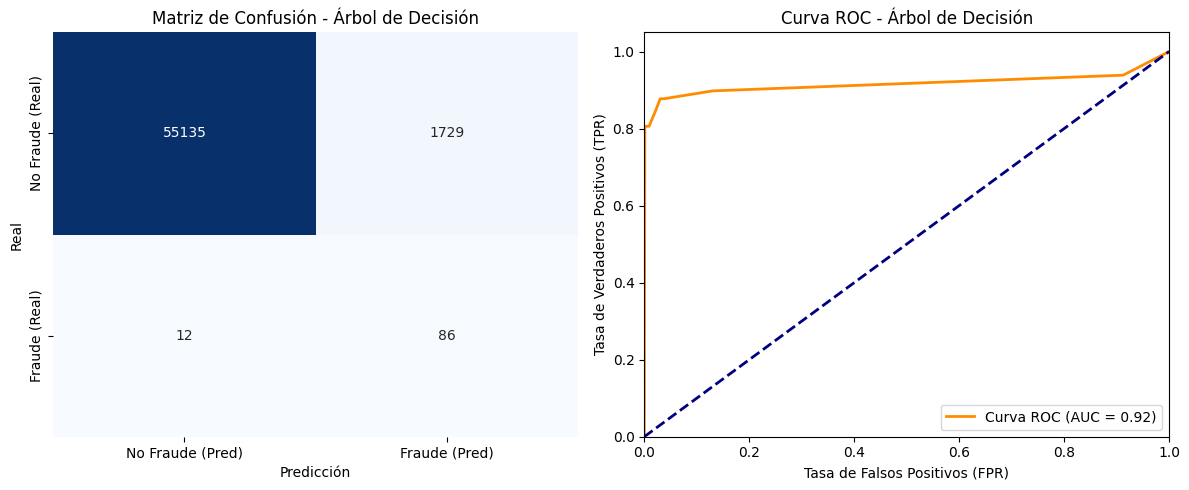

/tmp/ipykernel_274/1349967286.py:11: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(y_test) and set(y_test.cat.categories) == {'0', '1'}:



--- Evaluación del Modelo: Bosque Aleatorio ---
Exactitud (Accuracy): 0.9995

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



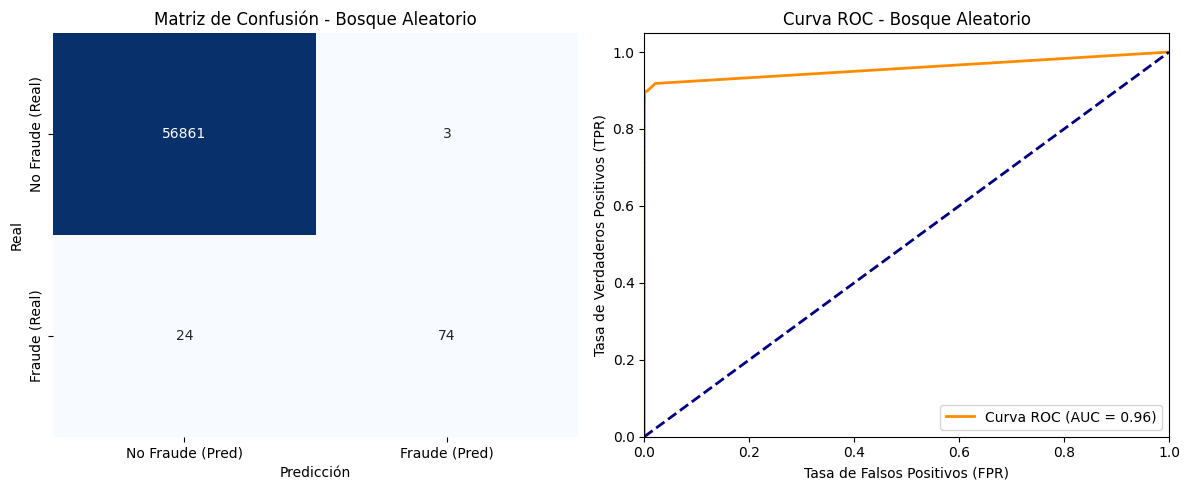


--- Comparación de Modelos ---
Análisis: El Bosque Aleatorio generalmente supera al Árbol de Decisión individual, especialmente en problemas desbalanceados, debido a su naturaleza de ensamble que reduce la varianza y el sobreajuste. Observando los valores de Recall para la clase '1' (fraude) y el AUC, podemos determinar qué modelo es más efectivo en la detección de fraudes reales, minimizando la pérdida de casos fraudulentos. Un recall alto para la clase de fraude es a menudo más importante que la precisión general en detección de fraude.


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Importar pandas para pd.api.types

def evaluate_and_plot_model(model, X_test, y_test, model_name):
    # Convertir y_test a tipo numérico si es categórico con '0' y '1'
    # Esto resuelve el ValueError en roc_curve y asegura la consistencia para otras métricas
    # La columna 'Class' de fetch_openml viene como categórica con categorías '0' y '1' (strings).
    # sklearn.metrics espera 0 y 1 (integers).
    if pd.api.types.is_categorical_dtype(y_test) and set(y_test.cat.categories) == {'0', '1'}:
        y_test_numeric = y_test.astype(int)
    else:
        y_test_numeric = y_test

    y_pred = model.predict(X_test)
    # Convertir y_pred a tipo numérico si los modelos predicen categóricas o strings
    # Esto asegura que y_pred y y_test_numeric sean del mismo tipo
    y_pred = y_pred.astype(int)

    y_pred_proba = model.predict_proba(X_test)[:, 1] # Probabilidades para la clase positiva (fraude)

    print(f"\n--- Evaluación del Modelo: {model_name} ---")
    # Usar y_test_numeric para todas las métricas de sklearn
    print(f"Exactitud (Accuracy): {accuracy_score(y_test_numeric, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test_numeric, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test_numeric, y_pred)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Fraude (Pred)', 'Fraude (Pred)'],
                yticklabels=['No Fraude (Real)', 'Fraude (Real)'])
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusión - {model_name}')

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'Curva ROC - {model_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Evaluar el modelo de Árbol de Decisión
evaluate_and_plot_model(dtc_model, X_test_scaled, y_test, 'Árbol de Decisión')

# Evaluar el modelo de Bosque Aleatorio
evaluate_and_plot_model(rf_model, X_test_scaled, y_test, 'Bosque Aleatorio')

print("\n--- Comparación de Modelos ---")
print("Análisis: El Bosque Aleatorio generalmente supera al Árbol de Decisión individual, especialmente en problemas desbalanceados, debido a su naturaleza de ensamble que reduce la varianza y el sobreajuste. Observando los valores de Recall para la clase '1' (fraude) y el AUC, podemos determinar qué modelo es más efectivo en la detección de fraudes reales, minimizando la pérdida de casos fraudulentos. Un recall alto para la clase de fraude es a menudo más importante que la precisión general en detección de fraude.")

### 5. Visualización del Árbol de Decisión

La visualización del Árbol de Decisión nos permite entender las reglas de decisión que el modelo ha aprendido. Podemos ver cómo el árbol divide los datos basándose en los valores de las características para clasificar entre 'no fraude' y 'fraude'.

**Justificación:** Esta visualización es clave para la interpretabilidad del modelo. Nos muestra las características más importantes y cómo interactúan para tomar una decisión de clasificación. Es especialmente útil para comunicar los hallazgos a partes interesadas no técnicas.

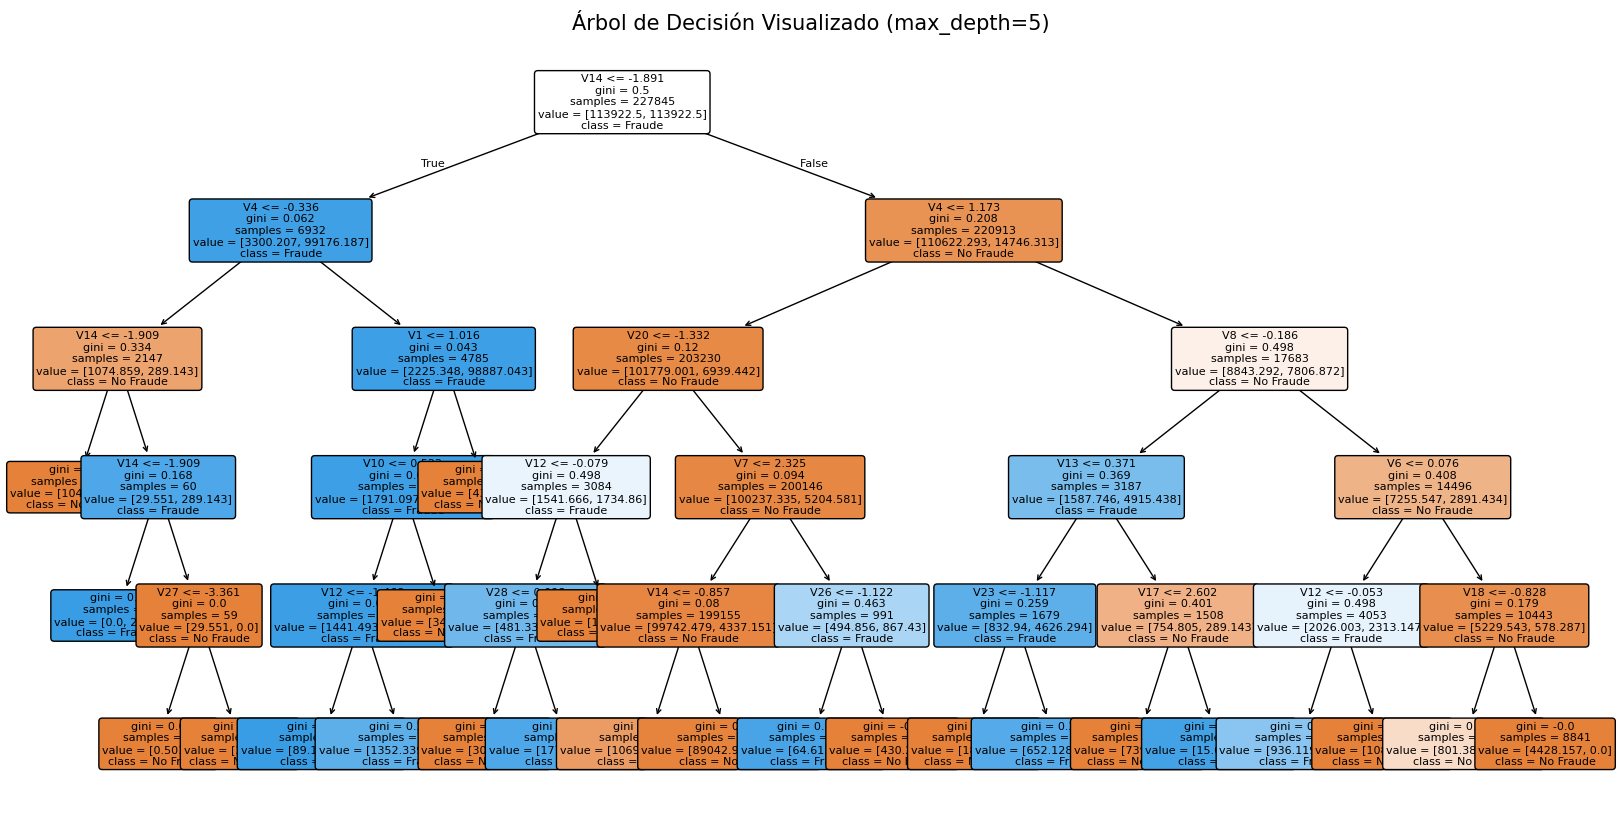


Análisis de la Visualización del Árbol de Decisión:
Cada nodo en el árbol representa una decisión basada en una característica y un umbral. Si el valor de la característica es menor o igual al umbral, sigue el camino de la izquierda; de lo contrario, el de la derecha. El color del nodo indica la clase mayoritaria en ese nodo (azul para 'no fraude', naranja para 'fraude'). Los 'samples' muestran cuántas instancias de datos cayeron en ese nodo, y los 'values' muestran la distribución de clases. La 'gini' es la impureza del nodo, indicando cuán mezcladas están las clases en ese nodo. Los nodos hoja (finales) tienen una alta pureza de una sola clase.
Esta visualización ayuda a identificar qué características son más influyentes en las primeras divisiones (más cerca de la raíz) y a entender las reglas específicas que el modelo utiliza para detectar el fraude.


In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10)) # Ajusta el tamaño para mejor visibilidad
plot_tree(dtc_model,
          feature_names=X.columns.tolist(), # Nombres de las características
          class_names=['No Fraude', 'Fraude'], # Nombres de las clases
          filled=True, # Rellenar nodos con colores de clase
          rounded=True, # Bordes redondeados
          fontsize=8) # Tamaño de fuente
plt.title('Árbol de Decisión Visualizado (max_depth=5)', fontsize=15)
plt.show()

print("\nAnálisis de la Visualización del Árbol de Decisión:")
print("Cada nodo en el árbol representa una decisión basada en una característica y un umbral. Si el valor de la característica es menor o igual al umbral, sigue el camino de la izquierda; de lo contrario, el de la derecha. El color del nodo indica la clase mayoritaria en ese nodo (azul para 'no fraude', naranja para 'fraude'). Los 'samples' muestran cuántas instancias de datos cayeron en ese nodo, y los 'values' muestran la distribución de clases. La 'gini' es la impureza del nodo, indicando cuán mezcladas están las clases en ese nodo. Los nodos hoja (finales) tienen una alta pureza de una sola clase.")
print("Esta visualización ayuda a identificar qué características son más influyentes en las primeras divisiones (más cerca de la raíz) y a entender las reglas específicas que el modelo utiliza para detectar el fraude.")